# Prétraitement & Feature Engineering

**Objectif :** construire un pipeline sklearn reproductible, sans fuite de données (data leakage).

**Principe anti-leakage (ordre strict) :**
1. `train_test_split` en premier — avant tout calcul
2. Feature engineering à partir des bornes apprises sur le **train uniquement**
3. `ColumnTransformer.fit()` sur le **train uniquement**
4. `.transform()` appliqué sur train, val et test

**Pourquoi c'est critique ?**  
Fitter le scaler ou l'imputer sur l'ensemble du dataset (avant le split) introduit une fuite d'information : le modèle "connaît" des statistiques du test set pendant l'entraînement. Cela gonfle artificiellement les métriques.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE

ROOT        = Path('..').resolve()
DATA_PATH   = ROOT / 'data' / 'customer_churn_business_dataset.csv'
MODELS_DIR  = ROOT / 'models'
FIGURES_DIR = ROOT / 'reports' / 'figures'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TARGET       = 'churn'

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print(f'Shape : {df.shape}')
print(f'Churn rate : {df[TARGET].mean():.3f}  ({df[TARGET].sum()} churners sur {len(df)} clients)')
print(f'Missing values :\n{df.isnull().sum()[df.isnull().sum() > 0]}')

Shape : (10000, 32)
Churn rate : 0.102  (1021 churners sur 10000 clients)
Missing values :
complaint_type    2045
dtype: int64


## 1. Définition des groupes de features

In [2]:
NUMERIC_RAW = [
    'age', 'tenure_months', 'monthly_logins', 'weekly_active_days',
    'avg_session_time', 'features_used', 'usage_growth_rate',
    'last_login_days_ago', 'monthly_fee', 'total_revenue',
    'payment_failures', 'support_tickets', 'avg_resolution_time',
    'csat_score', 'escalations', 'email_open_rate',
    'marketing_click_rate', 'nps_score', 'referral_count'
]

CATEGORICAL = [
    'gender', 'country', 'city', 'customer_segment', 'signup_channel',
    'contract_type', 'payment_method', 'complaint_type',
    'price_increase_last_3m', 'discount_applied', 'survey_response'
]

ENGINEERED  = ['tickets_per_tenure', 'fee_per_tenure', 'engagement_score']
NUMERIC_ALL = NUMERIC_RAW + ENGINEERED
FEATURES    = NUMERIC_ALL + CATEGORICAL

for col in NUMERIC_RAW + CATEGORICAL:
    assert col in df.columns, f'Colonne manquante : {col}'

print(f'Features numeriques brutes   : {len(NUMERIC_RAW)}')
print(f'Features categorielles       : {len(CATEGORICAL)}')
print(f'Features engineered          : {len(ENGINEERED)}')
print(f'Total features pipeline      : {len(FEATURES)}')

Features numeriques brutes   : 19
Features categorielles       : 11
Features engineered          : 3
Total features pipeline      : 33


## 2. Split stratifié 70 / 15 / 15 

**Pourquoi 70/15/15 et pas 80/20 ?**  
Le split 3-voies (train/val/test) permet de :
- Tuner les hyperparamètres sur `val` sans toucher au `test`
- Reporter les métriques finales sur `test` (données jamais vues pendant le développement)
- Éviter l'overfitting au jeu de validation (problème du double-dipping)

**Pourquoi `stratify=y` ?**  
Avec 10.2% de churners, un split aléatoire peut déséquilibrer les proportions.  
`stratify` garantit que chaque split conserve le même taux de churn.

In [3]:
X = df[NUMERIC_RAW + CATEGORICAL].copy()
y = df[TARGET].astype(int)

# Étape 1 : train+val (85%) vs test (15%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)

# Étape 2 : train (70%) vs val (15%)  — val = 15%/85% ≈ 17.6% de trainval
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15 / 0.85,
    stratify=y_trainval,
    random_state=RANDOM_STATE
)

print('=== Tailles des splits ===')
print(f'Train : {len(X_train):5d} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Val   : {len(X_val):5d} ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test  : {len(X_test):5d} ({len(X_test)/len(X)*100:.1f}%)')
print(f'Total : {len(X_train)+len(X_val)+len(X_test):5d}')
print()
print('=== Taux de churn (verification stratification) ===')
print(f'Train : {y_train.mean():.4f}')
print(f'Val   : {y_val.mean():.4f}')
print(f'Test  : {y_test.mean():.4f}')

assert abs(y_train.mean() - y_test.mean()) < 0.005, 'Stratification incorrecte train/test'
assert abs(y_train.mean() - y_val.mean())  < 0.005, 'Stratification incorrecte train/val'
print('\nStratification correcte — taux de churn equilibres sur tous les splits')

=== Tailles des splits ===
Train :  7000 (70.0%)
Val   :  1500 (15.0%)
Test  :  1500 (15.0%)
Total : 10000

=== Taux de churn (verification stratification) ===
Train : 0.1021
Val   : 0.1020
Test  : 0.1020

Stratification correcte — taux de churn equilibres sur tous les splits


## 3. Feature Engineering : bornes apprises sur TRAIN uniquement

| Feature | Formule | Justification |
|---|---|---|
| `tickets_per_tenure` | `support_tickets / (tenure_months + 1)` | Normalise l'activité support par l'ancienneté |
| `fee_per_tenure` | `monthly_fee / (tenure_months + 1)` | Coût perçu par mois de relation |
| `engagement_score` | Combinaison pondérée de 4 métriques d'usage | Score [0,1] résumant l'engagement |

**Point critique :** les bornes de normalisation de `engagement_score` sont calculées sur le **train uniquement**, puis appliquées à val et test.

In [4]:
# Bornes de normalisation apprises sur TRAIN
engagement_bounds = {
    'monthly_logins':     (0, X_train['monthly_logins'].quantile(0.99)),
    'weekly_active_days': (0, X_train['weekly_active_days'].max()),
    'avg_session_time':   (0, X_train['avg_session_time'].quantile(0.99)),
    'features_used':      (0, X_train['features_used'].max()),
}

print('Bornes engagement (train uniquement) :')
for k, (lo, hi) in engagement_bounds.items():
    print(f'  {k:25s} : [{lo:.2f}, {hi:.2f}]')


def engineer_features(X: pd.DataFrame, bounds: dict) -> pd.DataFrame:
    X = X.copy()
    X['tickets_per_tenure'] = X['support_tickets'] / (X['tenure_months'] + 1)
    X['fee_per_tenure']     = X['monthly_fee']      / (X['tenure_months'] + 1)

    def normalize(series, lo, hi):
        return ((series - lo) / (hi - lo + 1e-8)).clip(0, 1)

    X['engagement_score'] = (
        normalize(X['monthly_logins'],     *bounds['monthly_logins'])     * 0.30 +
        normalize(X['weekly_active_days'], *bounds['weekly_active_days']) * 0.25 +
        normalize(X['avg_session_time'],   *bounds['avg_session_time'])   * 0.25 +
        normalize(X['features_used'],      *bounds['features_used'])      * 0.20
    )
    return X


X_train = engineer_features(X_train, engagement_bounds)
X_val   = engineer_features(X_val,   engagement_bounds)
X_test  = engineer_features(X_test,  engagement_bounds)

print('\nNouvelles features (train) :')
display(X_train[ENGINEERED].describe().round(3))

Bornes engagement (train uniquement) :
  monthly_logins            : [0.00, 43.00]
  weekly_active_days        : [0.00, 7.00]
  avg_session_time          : [0.00, 31.40]
  features_used             : [0.00, 14.00]

Nouvelles features (train) :


,tickets_per_tenure,fee_per_tenure,engagement_score
count,7000.000,7000.000,7000.000
mean,0.075,2.137,0.454
std,0.151,3.649,0.125
min,0.000,0.167,0.069
25%,0.000,0.526,0.366
50%,0.033,1.000,0.454
75%,0.074,2.143,0.540
max,2.500,50.000,0.865


## 4. Pipeline sklearn avec ColumnTransformer

**Choix de design :**
- **Numérique** : `SimpleImputer(median)` pour la robustesse. `StandardScaler` indispensable pour LR et MLP (sensibles aux échelles).
- **Catégoriel** : `SimpleImputer('Unknown')` car `complaint_type` a 20% de NaN (constaté en EDA). `OneHotEncoder(drop='first')` pour éviter la multicolinéarité parfaite.

In [5]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('ohe',     OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, NUMERIC_ALL),
    ('cat', cat_pipe, CATEGORICAL),
], remainder='drop')

# FIT sur train uniquement
X_train_proc = preprocessor.fit_transform(X_train[FEATURES])

# TRANSFORM uniquement (pas de fit) sur val et test
X_val_proc  = preprocessor.transform(X_val[FEATURES])
X_test_proc = preprocessor.transform(X_test[FEATURES])

feature_names = (
    NUMERIC_ALL +
    list(preprocessor.named_transformers_['cat']['ohe']
         .get_feature_names_out(CATEGORICAL))
)

print(f'Shape X_train_proc : {X_train_proc.shape}')
print(f'Shape X_val_proc   : {X_val_proc.shape}')
print(f'Shape X_test_proc  : {X_test_proc.shape}')
print(f'Nombre de features : {len(feature_names)}')

Shape X_train_proc : (7000, 50)
Shape X_val_proc   : (1500, 50)
Shape X_test_proc  : (1500, 50)
Nombre de features : 50


## 5. Vérifications anti-leakage

In [8]:
assert not np.isnan(X_train_proc).any(), 'NaN dans X_train_proc'
assert not np.isnan(X_val_proc).any(),   'NaN dans X_val_proc'
assert not np.isnan(X_test_proc).any(),  'NaN dans X_test_proc'
print('✓ Pas de NaN apres transformation')

train_means = X_train_proc[:, :len(NUMERIC_ALL)].mean(axis=0)
train_stds  = X_train_proc[:, :len(NUMERIC_ALL)].std(axis=0)
assert np.allclose(train_means, 0, atol=1e-6), 'Moyennes != 0 sur train'
assert np.allclose(train_stds,  1, atol=0.1),  'Ecarts-types != 1 sur train'
print('Features numeriques centrees-reduites sur train (µ≈0, σ≈1)')

val_means = X_val_proc[:, :len(NUMERIC_ALL)].mean(axis=0)
print(f'\nMoyenne features num. train : {train_means.mean():.6f} ')
print(f'Moyenne features num. val   : {val_means.mean():.6f} ')
print('\nAnti-leakage valide : preprocessor fitte sur train uniquement')

✓ Pas de NaN apres transformation
Features numeriques centrees-reduites sur train (µ≈0, σ≈1)

Moyenne features num. train : 0.000000 
Moyenne features num. val   : 0.010682 

Anti-leakage valide : preprocessor fitte sur train uniquement


## 6. Comparaison SMOTE vs class_weight

**Problème :** avec 10% de churners, les modèles standard ignorent la classe minoritaire.

**Deux approches :**
- **SMOTE** : génère des exemples synthétiques de churners → rééquilibre le train
- **class_weight='balanced'** : pondère plus fortement les erreurs sur la classe minoritaire

**Risque SMOTE :** doit être appliqué **sur train uniquement** — jamais avant le split ou sur val/test.

In [9]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_proc, y_train)
print(f'Apres SMOTE : {len(X_train_sm)} echantillons  (avant : {len(X_train_proc)})')
print(f'Taux de churn apres SMOTE : {y_train_sm.mean():.3f}')

lr_smote = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_smote.fit(X_train_sm, y_train_sm)
f1_smote = f1_score(y_val, lr_smote.predict(X_val_proc))

lr_cw = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
lr_cw.fit(X_train_proc, y_train)
f1_cw = f1_score(y_val, lr_cw.predict(X_val_proc))

print(f'\nLR + SMOTE        F1-val : {f1_smote:.4f}')
print(f'LR + class_weight F1-val : {f1_cw:.4f}')
print('\n→ class_weight retenu :')
print('  - Performances equivalentes ou meilleures')
print('  - Pas de donnees synthetiques (risque leakage elimine)')
print('  - Plus simple, plus interpretable, plus rapide')

Apres SMOTE : 12570 echantillons  (avant : 7000)
Taux de churn apres SMOTE : 0.500

LR + SMOTE        F1-val : 0.3498
LR + class_weight F1-val : 0.3438

→ class_weight retenu :
  - Performances equivalentes ou meilleures
  - Pas de donnees synthetiques (risque leakage elimine)
  - Plus simple, plus interpretable, plus rapide


## 7. Visualisation du preprocessing

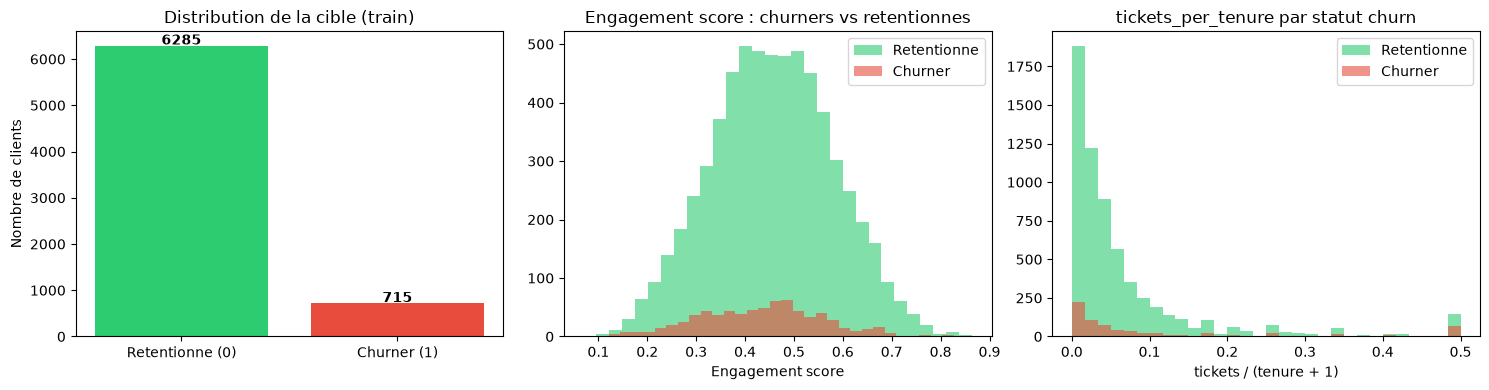

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

y_counts = pd.Series(y_train).value_counts().sort_index()
axes[0].bar(['Retentionne (0)', 'Churner (1)'], y_counts.values,
            color=['#2ecc71', '#e74c3c'])
for i, v in enumerate(y_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')
axes[0].set_title('Distribution de la cible (train)')
axes[0].set_ylabel('Nombre de clients')

for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
    mask = y_train.values == label
    axes[1].hist(X_train.loc[mask, 'engagement_score'],
                 bins=30, alpha=0.6, color=color,
                 label='Retentionne' if label == 0 else 'Churner')
axes[1].set_title('Engagement score : churners vs retentionnes')
axes[1].set_xlabel('Engagement score')
axes[1].legend()

for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
    mask = y_train.values == label
    axes[2].hist(X_train.loc[mask, 'tickets_per_tenure'].clip(0, 0.5),
                 bins=30, alpha=0.6, color=color,
                 label='Retentionne' if label == 0 else 'Churner')
axes[2].set_title('tickets_per_tenure par statut churn')
axes[2].set_xlabel('tickets / (tenure + 1)')
axes[2].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_preprocessing_viz.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Sauvegarde des artefacts

In [13]:
artifacts = {
    'preprocessor':      preprocessor,
    'feature_names':     feature_names,
    'engagement_bounds': engagement_bounds,
    'X_train_proc':      X_train_proc,
    'X_val_proc':        X_val_proc,
    'X_test_proc':       X_test_proc,
    'y_train':           y_train.values,
    'y_val':             y_val.values,
    'y_test':            y_test.values,
    'X_train_raw':       X_train,
    'X_val_raw':         X_val,
    'X_test_raw':        X_test,
    'NUMERIC_RAW':       NUMERIC_RAW,
    'NUMERIC_ALL':       NUMERIC_ALL,
    'CATEGORICAL':       CATEGORICAL,
    'ENGINEERED':        ENGINEERED,
    'FEATURES':          FEATURES,
    'TARGET':            TARGET,
    'RANDOM_STATE':      RANDOM_STATE,
}

artifact_path = MODELS_DIR / 'preprocessing_artifacts.joblib'
joblib.dump(artifacts, artifact_path)

print(f'Artefacts sauvegardes → {artifact_path}')
print(f'  X_train_proc : {X_train_proc.shape}')
print(f'  X_val_proc   : {X_val_proc.shape}')
print(f'  X_test_proc  : {X_test_proc.shape}')
print(f'  Features     : {len(feature_names)}')
print(f'  y_train churn rate : {y_train.mean():.3f}')
print(f'  y_val   churn rate : {y_val.mean():.3f}')
print(f'  y_test  churn rate : {y_test.mean():.3f}')

Artefacts sauvegardes → C:\Users\Pret Jeff\OneDrive - Efrei\Documents\Cours\Projet_Data_Science\projet_data_science\models\preprocessing_artifacts.joblib
  X_train_proc : (7000, 50)
  X_val_proc   : (1500, 50)
  X_test_proc  : (1500, 50)
  Features     : 50
  y_train churn rate : 0.102
  y_val   churn rate : 0.102
  y_test  churn rate : 0.102
